In [1]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt

In [16]:
%pip install -e ..

Obtaining file:///glade/u/home/qingyuany/repos/spatialtuning
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for proj2dhullsampler (pyproject.toml) ... done
  Created wheel for proj2dhullsampler: filename=proj2dhullsampler-0.1.0-0.editable-py3-none-any.whl size=5017 sha256=25a009e28221551a772608021348cf455a4b958cca8018481af749089e91b6e3
  Stored in directory: /glade/derecho/scratch/qingyuany/tmp/pip-ephem-wheel-cache-vynsc3lk/wheels/50/4e/df/9c5238c00171ab2ac4c6ca37824caa82a453cfc9707feec53b
Successfully built proj2dhullsampler
  Attempting uninstall: proj2dhullsampler
    Found existing installation: proj2dhullsampler 0.1.0
    Uninstalling proj2dhullsampler-0.1.0:
      Successfully uninstalled proj2dhullsampler-0.1.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from proj2dhullsampler import HistoryMatching

In [3]:
working_dir = '/glade/work/qingyuany/repo_data/'
case_name = "proj2dsampler_test"
result_name = 'sample1'

In [4]:
test_case = HistoryMatching(working_dir, case_name)
test_case.load_case()
test_case.load_mask(threshold_level=2.0)


In [5]:
test_case.drop_by_name(["local_PRECT_4_7_1_359"])
test_case.drop_by_n_survive(n_survive = 10000)

In [6]:
test_case.group_para_climatology(overlapping_threshold = 10000)
summary2d = test_case.shuffle_vars()

cldfrc_dp1                               and microp_aero_wsubi_scale                 :        0
microp_aero_wsubi_min                    and microp_aero_wsubi_scale                 :        0
zmconv_capelmt                           and microp_aero_wsubi_scale                 :        0
There are 3 groups that have no overlapping within own groups


In [7]:
list(summary2d.values())[2].head(10)

,var1,var2,count
0,filter_precip0999,filter_precip099,0


In [8]:
no_overlap_2d_vars = ['PRECT_zonal_-35to-15', 'PRECT_zonal_25to45', 'LWCF_zonal_25to45', 'FLUT_zonal_-75to-55', 'filter_precip099', 
                     'LWCF_zonal_-55to-35', 'FLUT_zonal_-15to5','LWCF_zonal_-35to-15']

In [9]:
test_case.drop_no_overlap2d_vars(no_overlap_2d_vars)
test_case.group_para_climatology()
summary2d = test_case.shuffle_vars()


There are 0 groups that have no overlapping within own groups
No non-overlapping variables at this stage for the variables sharing the same 2 sensitive parameters


IndexError: list index out of range

In [12]:
test_case.drop_by_nvar_per_pair(n_var_thre=1)

In [13]:
test_case.prepare_for_sampling(max_workers = 6)
test_case.draw(n_pts=50000, n_threshold=5000, sample_threshold=10**9, max_workers=10, n_max=1000)

Finish constructing the 2d polygons/convex hulls
Running ('cldfrc_dp1', 'microp_aero_wsubi_scale'), the 0th simulation
There is overlap for ('cldfrc_dp1', 'microp_aero_wsubi_scale'). Proceed to the next parameter pair
Running ('clubb_c1', 'microp_aero_npccn_scale'), the 1th simulation
There is overlap for ('clubb_c1', 'microp_aero_npccn_scale'). Proceed to the next parameter pair
Running ('clubb_c1', 'microp_aero_wsubi_scale'), the 2th simulation
There is overlap for ('clubb_c1', 'microp_aero_wsubi_scale'). Proceed to the next parameter pair
Running ('microp_aero_wsubi_min', 'microp_aero_wsubi_scale'), the 3th simulation
Find nothing from 100000 pts
Find nothing, try to resolve it by breaking the variables into groups
First sample out_prev that needs greater sample size, which will take long
The size of out_prev is 113
	 	Running test to see if ('microp_aero_wsubi_min', 'microp_aero_wsubi_scale') could be break down and lead to non-overlapping
Try 2 combinations
Try one of the combinat

In [14]:
test_case.save_samples_specifications('result5', top_n = 100)

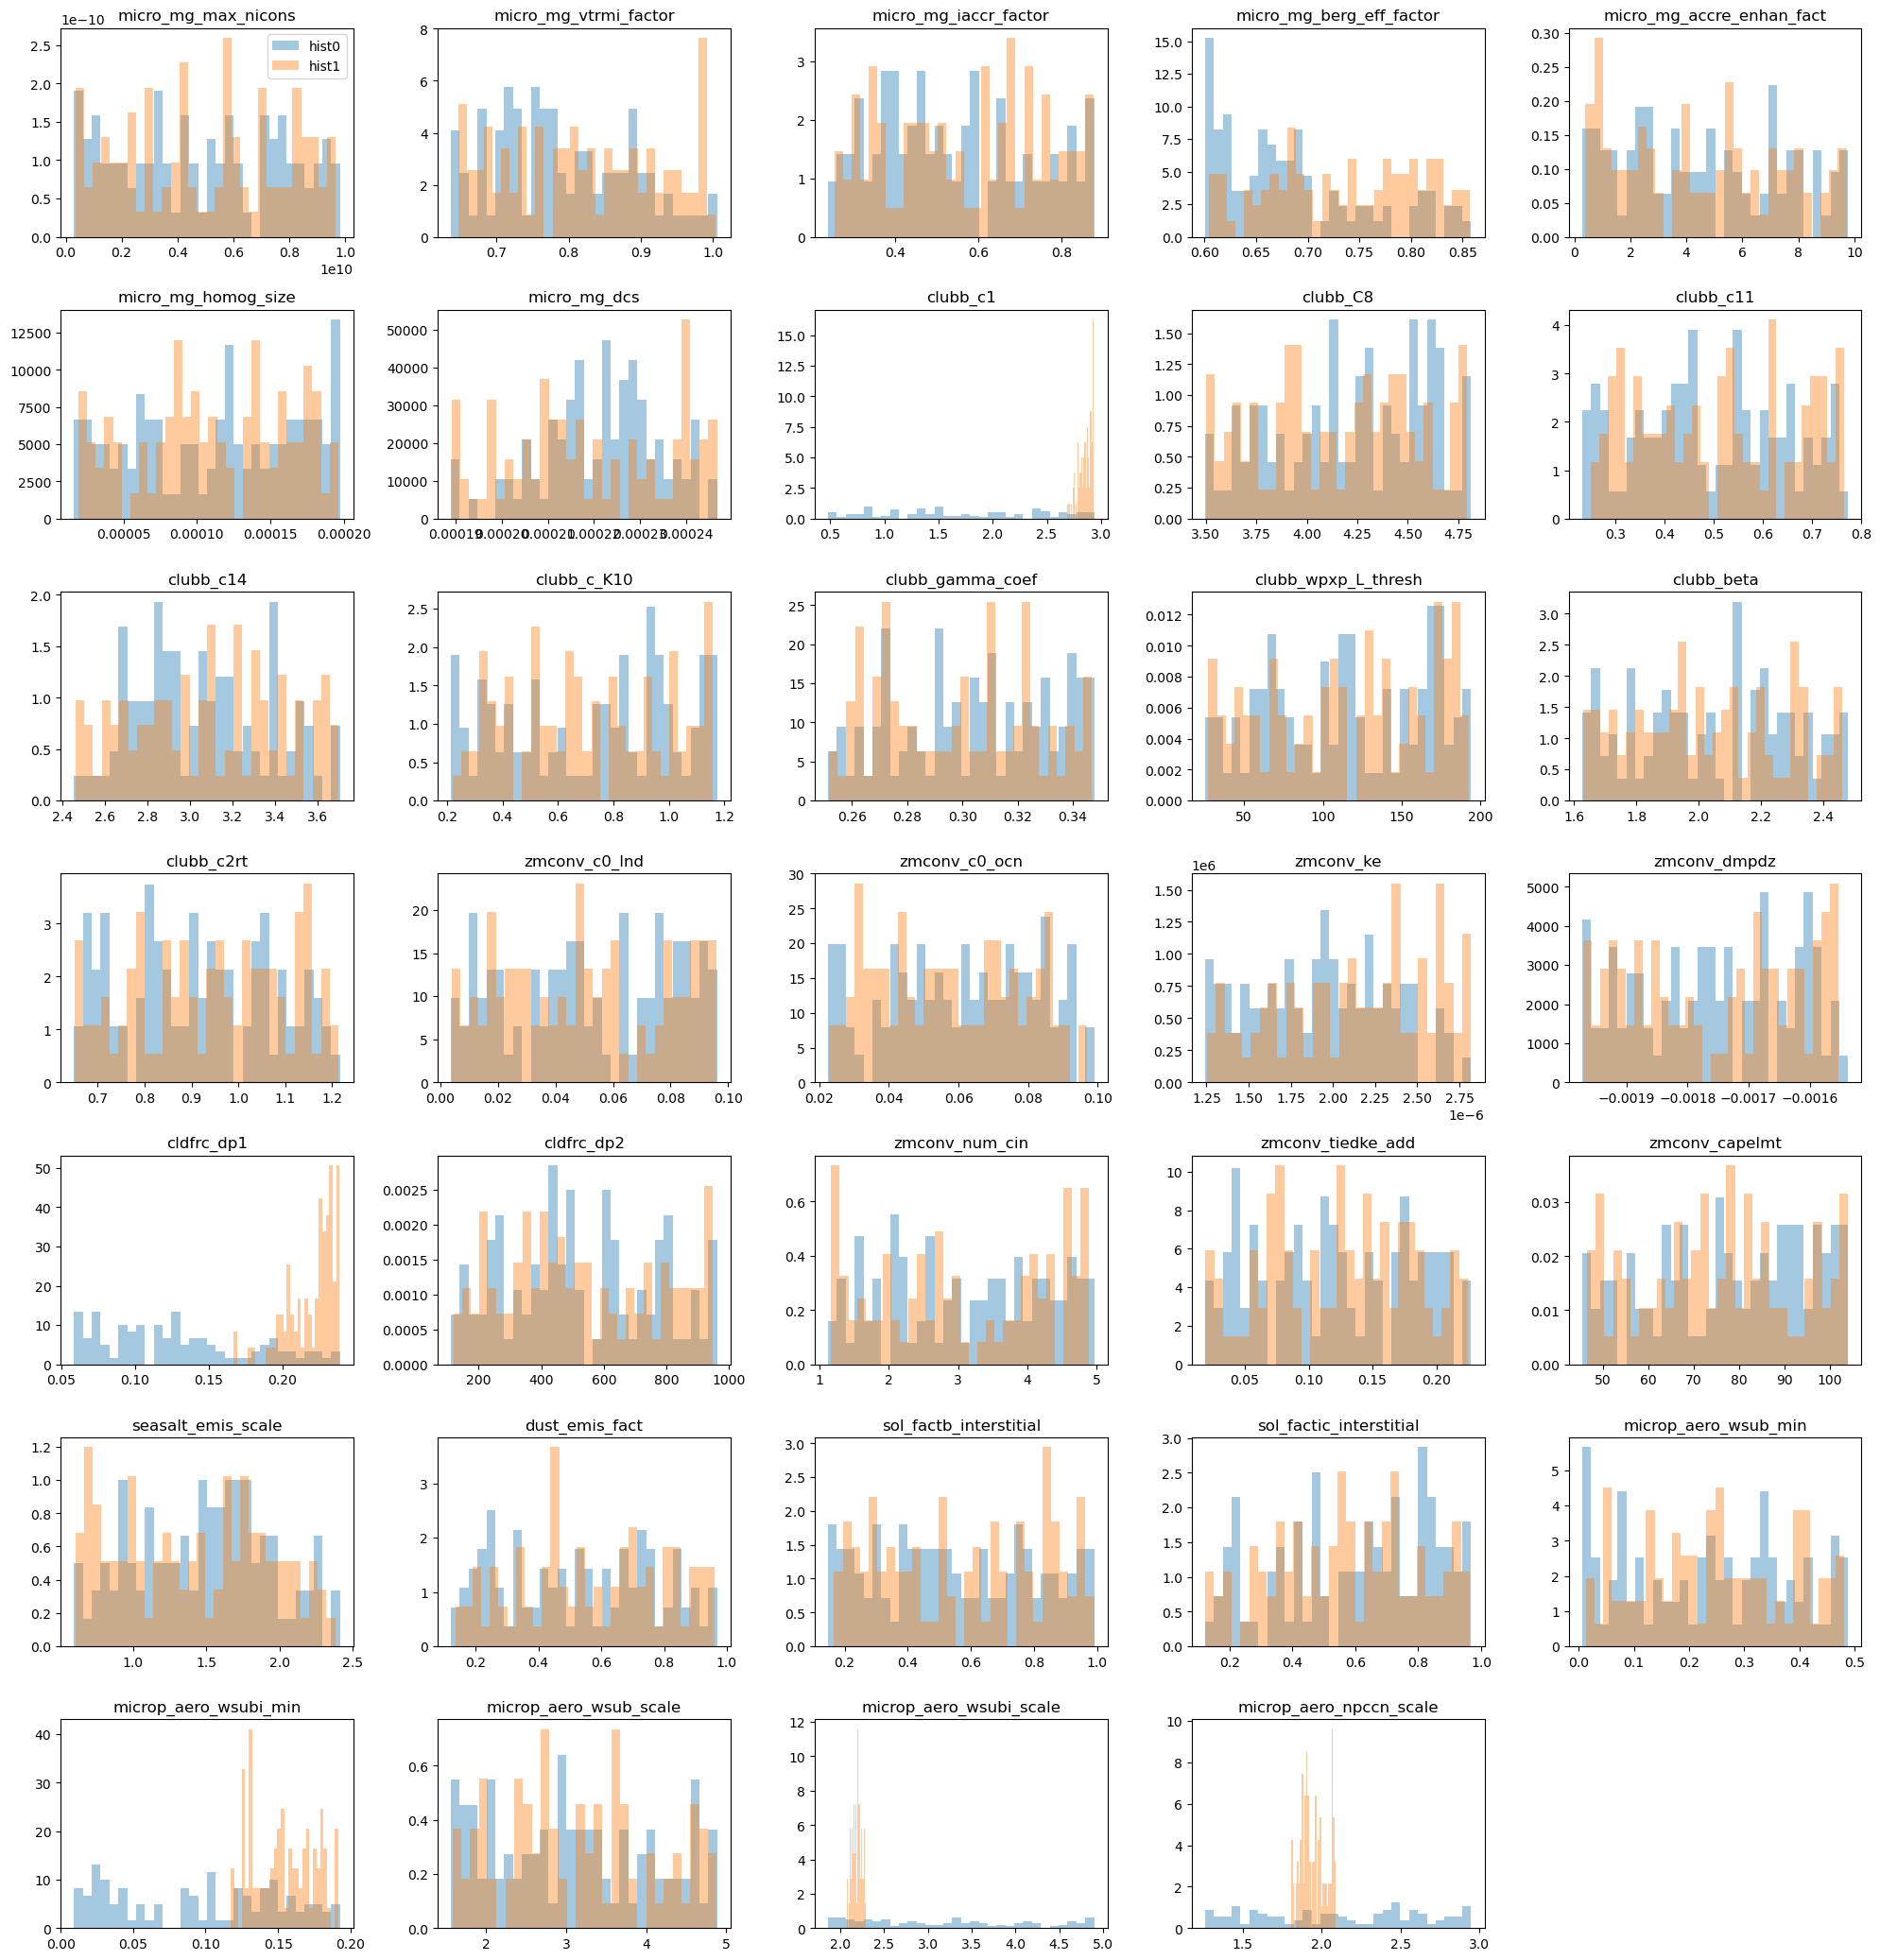

In [15]:
test_case.compare_with_original()